In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

BASE = Path("C:/Users/janku/Documents/KCL/Research Project/Research Project")
METRICS_DIR = BASE / "results" / "metrics"
FIG_DIR = BASE / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_png(fig, filename, dpi=300):
    out_path = FIG_DIR / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    return out_path


MODEL_FILES = {
    ("RADAR", "Random Forest"): METRICS_DIR / "RF" / "RADAR" / "radar_rf_summary.csv",
    ("RADAR", "MERF (RF)"): METRICS_DIR / "RF" / "RADAR" / "radar_merf_summary.csv",
    ("RADAR", "SVM"): METRICS_DIR / "SVM" / "RADAR" / "radar_svm_cv_summary.csv",
    ("RADAR", "MERF (SVR)"): METRICS_DIR / "SVM" / "MERF" / "RADAR" / "radar_merf_svr_summary.csv",
    ("RADAR", "Gradient Boosting Classifier"): METRICS_DIR / "GradBoost" / "RADAR" / "radar_xgbc_cv_summary.csv",
    ("RADAR", "GPBoost"): METRICS_DIR / "GradBoost" / "RADAR" / "radar_gpboost_cv_summary.csv",
    ("ANDROIDS", "Random Forest"): METRICS_DIR / "RF" / "ANDROIDS" / "androids_rf_summary.csv",
    ("ANDROIDS", "MERF (RF)"): METRICS_DIR / "RF" / "ANDROIDS" / "androids_merf_summary.csv",
    ("ANDROIDS", "SVM"): METRICS_DIR / "SVM" / "ANDROIDS" / "androids_svm_cv_summary.csv",
    ("ANDROIDS", "MERF (SVR)"): METRICS_DIR / "SVM" / "MERF" / "Androids" / "androids_merf_summary.csv",
    ("ANDROIDS", "Gradient Boosting Classifier"): METRICS_DIR / "GradBoost" / "Androids" / "androids_gbc_cv_summary.csv",
    ("ANDROIDS", "GPBoost"): METRICS_DIR / "GradBoost" / "Androids" / "androids_gpboost_cv_summary.csv",
}

WILCOXON_HELDOUT_FILES = {
    ("RADAR", "Gradient Boosting Classifier"): METRICS_DIR / "radar_xgbc_wilcoxon_heldout.csv",
    ("RADAR", "GPBoost"): METRICS_DIR / "radar_gpboost_wilcoxon_heldout.csv",
    ("ANDROIDS", "Gradient Boosting Classifier"): METRICS_DIR / "GradBoost" / "Androids" / "androids_gbc_wilcoxon_heldout.csv",
    ("ANDROIDS", "GPBoost"): METRICS_DIR / "GradBoost" / "Androids" / "androids_gpboost_wilcoxon_heldout.csv",
}

WILCOXON_CV_FILES = {
    ("RADAR", "Random Forest"): METRICS_DIR / "RF" / "RADAR" / "radar_rf_cv_folds.csv",
    ("RADAR", "MERF (RF)"): METRICS_DIR / "RF" / "RADAR" / "radar_merf_cv_folds.csv",
    ("RADAR", "MERF (SVR)"): METRICS_DIR / "SVM" / "MERF" / "RADAR" / "radar_merf_svr_cv_folds.csv",
    ("RADAR", "Gradient Boosting Classifier"): METRICS_DIR / "GradBoost" / "RADAR" / "radar_xgbc_cv_folds.csv",
    ("RADAR", "GPBoost"): METRICS_DIR / "GradBoost" / "RADAR" / "radar_gpboost_cv_folds.csv",
    ("ANDROIDS", "Random Forest"): METRICS_DIR / "RF" / "ANDROIDS" / "androids_rf_cv_folds.csv",
    ("ANDROIDS", "MERF (RF)"): METRICS_DIR / "RF" / "ANDROIDS" / "androids_merf_cv_folds.csv",
    ("ANDROIDS", "MERF (SVR)"): METRICS_DIR / "SVM" / "MERF" / "Androids" / "androids_merf_cv_folds.csv",
    ("ANDROIDS", "Gradient Boosting Classifier"): METRICS_DIR / "GradBoost" / "Androids" / "androids_gbc_cv_folds.csv",
    ("ANDROIDS", "GPBoost"): METRICS_DIR / "GradBoost" / "Androids" / "androids_gpboost_cv_folds.csv",
}


def load_metric_table(model_files):
    rows = []
    for (dataset, model), csv_path in model_files.items():
        if not csv_path.exists():
            print(f"Missing file: {csv_path}")
            continue

        d = pd.read_csv(csv_path)
        if d.empty:
            print(f"Empty file: {csv_path}")
            continue

        row = d.iloc[0].to_dict()
        row["dataset"] = dataset
        row["model"] = model
        row["source_file"] = str(csv_path)
        rows.append(row)

    return pd.DataFrame(rows)


def _extract_single_pvalue(df):
    p_cols = [c for c in df.columns if "wilcoxon" in c.lower() and "p" in c.lower()]
    if not p_cols:
        return np.nan
    return pd.to_numeric(df[p_cols[0]], errors="coerce").iloc[0]


def _extract_cv_mean_pvalue(df):
    p_cols = [c for c in df.columns if "wilcoxon" in c.lower() and "p" in c.lower()]
    if not p_cols:
        return np.nan
    return pd.to_numeric(df[p_cols[0]], errors="coerce").mean()


def build_wilcoxon_table():
    rows = []

    for (dataset, model), path in WILCOXON_HELDOUT_FILES.items():
        if not path.exists():
            continue
        d = pd.read_csv(path)
        if d.empty:
            continue
        p = _extract_single_pvalue(d)
        if pd.notna(p):
            rows.append(
                {
                    "dataset": dataset,
                    "model": model,
                    "source": "heldout",
                    "p_value": float(p),
                }
            )

    for (dataset, model), path in WILCOXON_CV_FILES.items():
        if not path.exists():
            continue
        d = pd.read_csv(path)
        if d.empty:
            continue
        p = _extract_cv_mean_pvalue(d)
        if pd.notna(p):
            rows.append(
                {
                    "dataset": dataset,
                    "model": model,
                    "source": "cv_mean",
                    "p_value": float(p),
                }
            )

    w = pd.DataFrame(rows)
    if w.empty:
        return w

    w["significant"] = w["p_value"] < 0.05
    w["sig_label"] = np.where(w["significant"], "*", "ns")
    return w


def get_preferred_wilcoxon_map(wilcoxon_df):
    if wilcoxon_df.empty:
        return {}
    ranked = wilcoxon_df.copy()
    ranked["source_rank"] = ranked["source"].map({"heldout": 0, "cv_mean": 1}).fillna(9)
    ranked = ranked.sort_values(["dataset", "model", "source_rank"]).drop_duplicates(["dataset", "model"])
    return {
        (r["dataset"], r["model"]): {"p_value": r["p_value"], "sig_label": r["sig_label"], "source": r["source"]}
        for _, r in ranked.iterrows()
    }


metrics_df = load_metric_table(MODEL_FILES)
wilcoxon_df = build_wilcoxon_table()
wilcoxon_map = get_preferred_wilcoxon_map(wilcoxon_df)

for metric in ["accuracy_mean", "f1_mean", "roc_auc_mean", "mae_mean", "rmse_mean", "r2_mean"]:
    if metric not in metrics_df.columns:
        metrics_df[metric] = np.nan

print(metrics_df[["dataset", "model", "accuracy_mean", "f1_mean", "roc_auc_mean", "rmse_mean"]])
print("\nWilcoxon p-values (heldout preferred, then CV mean):")
print(wilcoxon_df.sort_values(["dataset", "model", "source"]) if not wilcoxon_df.empty else "No Wilcoxon files found")

     dataset                         model  accuracy_mean   f1_mean  \
0      RADAR                 Random Forest       0.579213  0.333509   
1      RADAR                     MERF (RF)            NaN       NaN   
2      RADAR                           SVM       0.589900  0.184089   
3      RADAR                    MERF (SVR)            NaN       NaN   
4      RADAR  Gradient Boosting Classifier       0.562709  0.425639   
5      RADAR                       GPBoost       0.564384  0.229649   
6   ANDROIDS                 Random Forest       0.660606  0.693788   
7   ANDROIDS                     MERF (RF)            NaN       NaN   
8   ANDROIDS                           SVM       0.683535  0.755421   
9   ANDROIDS                    MERF (SVR)            NaN       NaN   
10  ANDROIDS  Gradient Boosting Classifier       0.596984  0.664484   
11  ANDROIDS                       GPBoost       0.569069  0.674403   

    roc_auc_mean  rmse_mean  
0       0.540611        NaN  
1            NaN

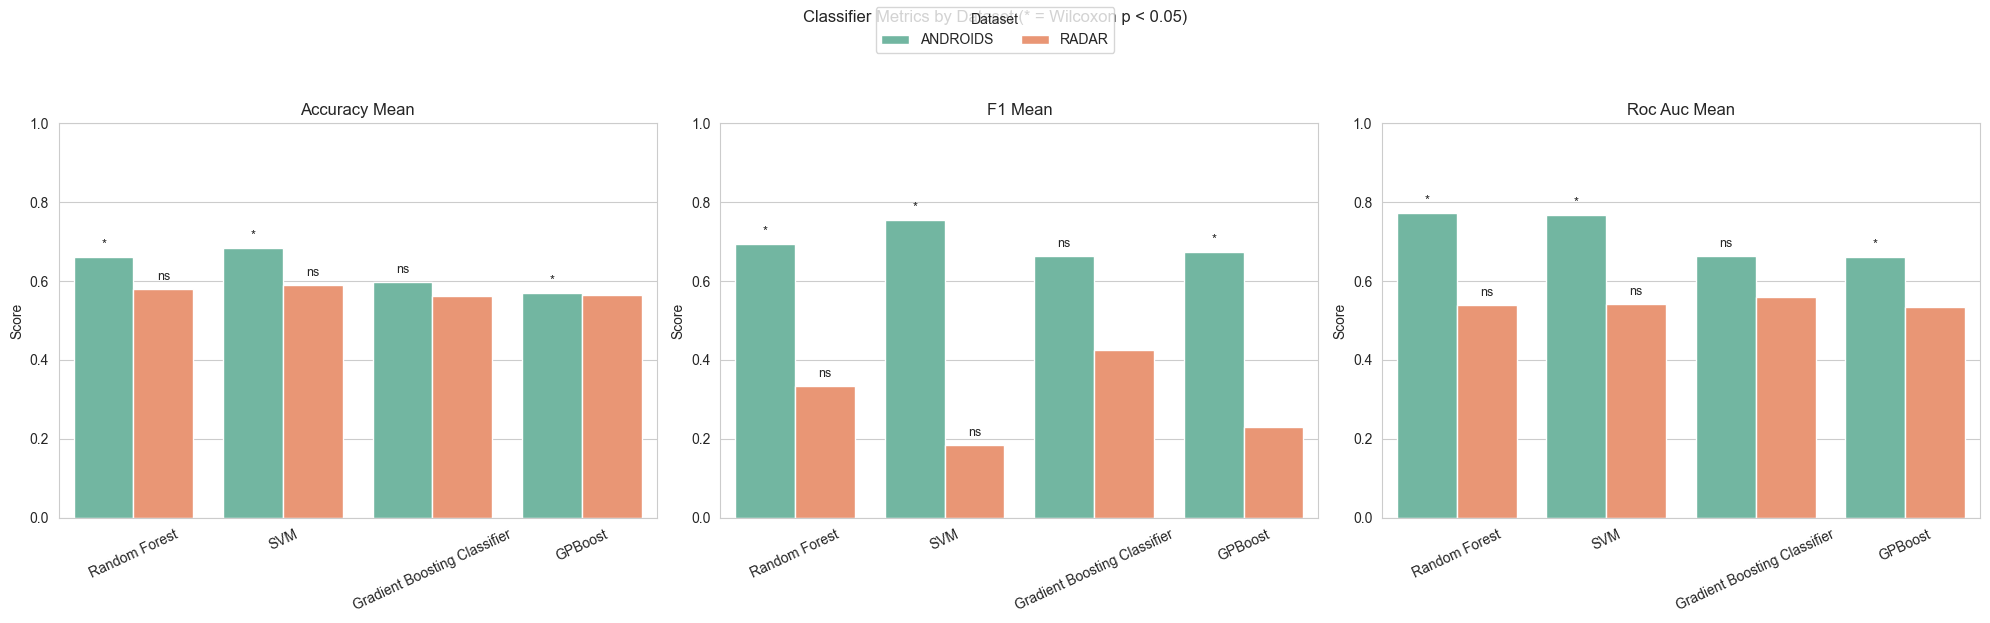

Saved: C:\Users\janku\Documents\KCL\Research Project\Research Project\results\figures\all_classifiers_metrics_with_wilcoxon.png


In [5]:
# 1) Bar graph comparison of all classifiers across metrics
# Wilcoxon significance marker on bars: '*' if p < 0.05, 'ns' otherwise

classification_metrics = ["accuracy_mean", "f1_mean", "roc_auc_mean"]
classifier_models = [
    "Random Forest",
    "SVM",
    "Gradient Boosting Classifier",
    "GPBoost",
]
datasets_order = sorted(metrics_df["dataset"].dropna().unique())

fig_cls, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for ax, metric in zip(axes, classification_metrics):
    plot_df = metrics_df[
        metrics_df["model"].isin(classifier_models)
    ][["dataset", "model", metric]].dropna().copy()

    sns.barplot(
        data=plot_df,
        x="model",
        y=metric,
        hue="dataset",
        order=classifier_models,
        hue_order=datasets_order,
        ax=ax,
        palette="Set2",
    )

    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(0, 1)

    # annotate significance from preferred Wilcoxon source
    for patch, (_, row) in zip(ax.patches, plot_df.sort_values(["model", "dataset"]).iterrows()):
        key = (row["dataset"], row["model"])
        if key not in wilcoxon_map:
            continue
        ann = wilcoxon_map[key]["sig_label"]
        y = patch.get_height()
        x = patch.get_x() + patch.get_width() / 2
        ax.text(x, y + 0.015, ann, ha="center", va="bottom", fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig_cls.legend(handles, labels, loc="upper center", ncol=2, title="Dataset")
fig_cls.suptitle("Classifier Metrics by Dataset (* = Wilcoxon p < 0.05)", y=1.03)
plt.tight_layout(rect=(0, 0, 1, 0.95))

bar_cls_path = save_png(fig_cls, "all_classifiers_metrics_with_wilcoxon.png")
plt.show()
print(f"Saved: {bar_cls_path}")

Delta rows (basic - mixed):
    dataset                                    pair    metric     delta
0  ANDROIDS  Gradient Boosting Classifier - GPBoost  accuracy  0.027915
1  ANDROIDS  Gradient Boosting Classifier - GPBoost        f1 -0.009919
2  ANDROIDS  Gradient Boosting Classifier - GPBoost   roc_auc  0.000818
3     RADAR  Gradient Boosting Classifier - GPBoost  accuracy -0.001674
4     RADAR  Gradient Boosting Classifier - GPBoost        f1  0.195990
5     RADAR  Gradient Boosting Classifier - GPBoost   roc_auc  0.025759

Unavailable pair comparisons:
    dataset                        pair            reason
0  ANDROIDS  Random Forest vs MERF (RF)  no common metric
1  ANDROIDS           SVM vs MERF (SVR)  no common metric
2     RADAR  Random Forest vs MERF (RF)  no common metric
3     RADAR           SVM vs MERF (SVR)  no common metric


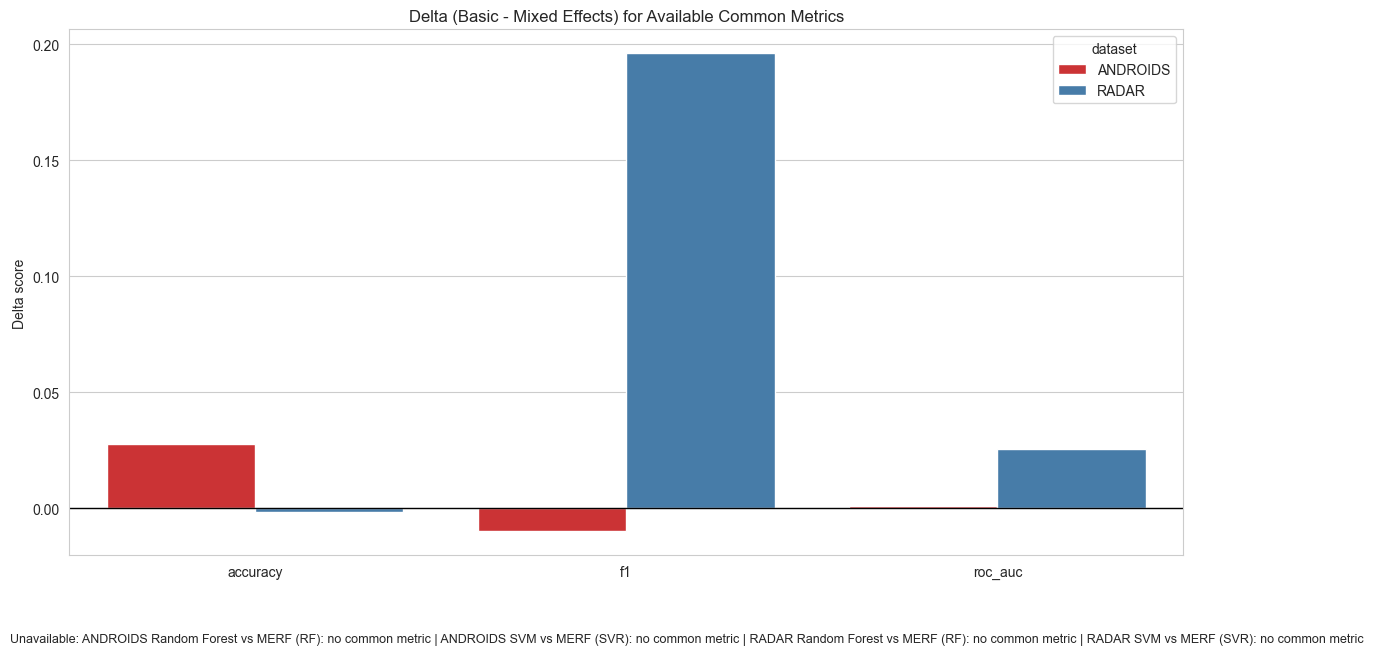

Saved: C:\Users\janku\Documents\KCL\Research Project\Research Project\results\figures\basic_vs_mixed_delta_rf_svr_gb.png


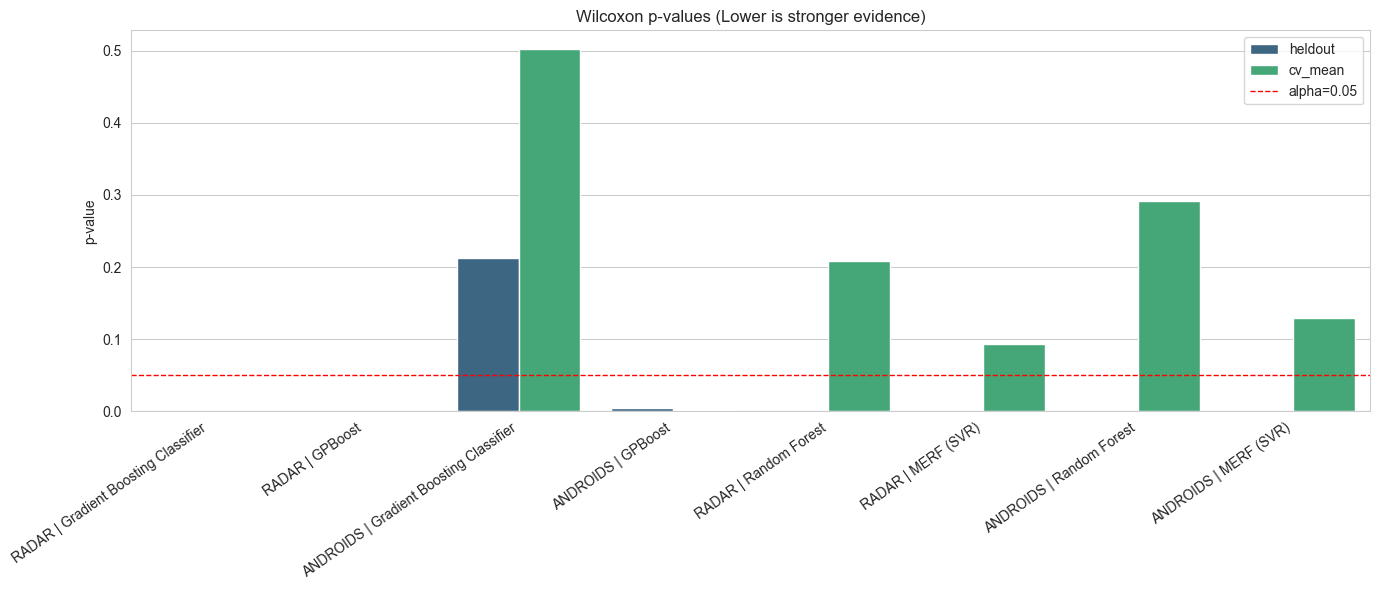

Saved: C:\Users\janku\Documents\KCL\Research Project\Research Project\results\figures\wilcoxon_pvalues_summary.png


In [6]:
# 2) Delta: basic model vs mixed-effects model (RF, SVR, GB)
# and explicit Wilcoxon visualization

pairs = [
    ("Random Forest", "MERF (RF)"),
    ("SVM", "MERF (SVR)"),
    ("Gradient Boosting Classifier", "GPBoost"),
]

metric_candidates = ["accuracy_mean", "f1_mean", "roc_auc_mean", "rmse_mean"]
delta_rows = []
unavailable_pairs = []

for dataset in sorted(metrics_df["dataset"].dropna().unique()):
    subset = metrics_df[metrics_df["dataset"] == dataset]

    for basic_name, mixed_name in pairs:
        b_row = subset[subset["model"] == basic_name]
        m_row = subset[subset["model"] == mixed_name]
        if b_row.empty or m_row.empty:
            unavailable_pairs.append({"dataset": dataset, "pair": f"{basic_name} vs {mixed_name}", "reason": "missing model row"})
            continue

        b_row = b_row.iloc[0]
        m_row = m_row.iloc[0]

        shared = [
            metric for metric in metric_candidates
            if pd.notna(b_row.get(metric, np.nan)) and pd.notna(m_row.get(metric, np.nan))
        ]

        if not shared:
            unavailable_pairs.append({"dataset": dataset, "pair": f"{basic_name} vs {mixed_name}", "reason": "no common metric"})
            continue

        for metric in shared:
            delta_rows.append(
                {
                    "dataset": dataset,
                    "pair": f"{basic_name} - {mixed_name}",
                    "metric": metric.replace("_mean", ""),
                    "delta": float(b_row[metric] - m_row[metric]),
                }
            )

delta_long = pd.DataFrame(delta_rows)
unavailable_df = pd.DataFrame(unavailable_pairs)

print("Delta rows (basic - mixed):")
print(delta_long if not delta_long.empty else "No computable deltas")
print("\nUnavailable pair comparisons:")
print(unavailable_df if not unavailable_df.empty else "None")

if not delta_long.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=delta_long,
        x="metric",
        y="delta",
        hue="dataset",
        palette="Set1",
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.title("Delta (Basic - Mixed Effects) for Available Common Metrics")
    plt.xlabel("")
    plt.ylabel("Delta score")

    if not unavailable_df.empty:
        unavailable_txt = " | ".join(
            unavailable_df.apply(lambda r: f"{r['dataset']} {r['pair']}: {r['reason']}", axis=1).tolist()
        )
        plt.figtext(0.01, -0.08, f"Unavailable: {unavailable_txt}", ha="left", fontsize=9)

    plt.tight_layout()
    fig = plt.gcf()
    delta_path = save_png(fig, "basic_vs_mixed_delta_rf_svr_gb.png")
    plt.show()
    print(f"Saved: {delta_path}")
else:
    print("No valid deltas could be computed.")

# 3) Wilcoxon p-values summary plot
if not wilcoxon_df.empty:
    w_plot = wilcoxon_df.copy()
    w_plot["dataset_model"] = w_plot["dataset"] + " | " + w_plot["model"]

    plt.figure(figsize=(14, 6))
    sns.barplot(
        data=w_plot,
        x="dataset_model",
        y="p_value",
        hue="source",
        palette="viridis",
    )
    plt.axhline(0.05, color="red", linestyle="--", linewidth=1, label="alpha=0.05")
    plt.title("Wilcoxon p-values (Lower is stronger evidence)")
    plt.xlabel("")
    plt.ylabel("p-value")
    plt.xticks(rotation=35, ha="right")
    plt.legend()
    plt.tight_layout()

    fig = plt.gcf()
    wilcoxon_path = save_png(fig, "wilcoxon_pvalues_summary.png")
    plt.show()
    print(f"Saved: {wilcoxon_path}")
else:
    print("No Wilcoxon files were found to plot.")